# Perceptron

Neste relatório, será implementado um Perceptron de camada única utilizando apenas NumPy. O algoritmo será inicialmente aplicado a dados linearmente separáveis e, posteriormente, a dados com sobreposição entre as classes, permitindo analisar seu processo de convergência e suas limitações.

# Exercise 1

## A — Generate the data

Para o primeiro exercício, foram geradas duas classes bidimensionais, cada uma contendo 1.000 amostras. Os pontos foram obtidos de distribuições normais multivariadas com médias distintas e a mesma matriz de covariância.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Único gerador de números aleatórios utilizado em todo o relatório
rng = np.random.default_rng(42)

In [2]:
# Quantidade de amostras por classe
n_samples = 1000

# Parâmetros da Classe 0
mean_class_0 = np.array([1.5, 1.5])

# Parâmetros da Classe 1
mean_class_1 = np.array([5.0, 5.0])

# Matriz de covariância utilizada nas duas classes
covariance = np.array([
    [0.5, 0.0],
    [0.0, 0.5]
])

# Geração das amostras de cada classe
X_class_0 = rng.multivariate_normal(
    mean=mean_class_0,
    cov=covariance,
    size=n_samples
)

X_class_1 = rng.multivariate_normal(
    mean=mean_class_1,
    cov=covariance,
    size=n_samples
)

# União das amostras em uma única matriz de atributos
X = np.vstack((X_class_0, X_class_1))

# Criação dos rótulos: 0 para a primeira classe e 1 para a segunda
y = np.concatenate((
    np.zeros(n_samples, dtype=int),
    np.ones(n_samples, dtype=int)
))

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"Quantidade de amostras da Classe 0: {np.sum(y == 0)}")
print(f"Quantidade de amostras da Classe 1: {np.sum(y == 1)}")

Formato de X: (2000, 2)
Formato de y: (2000,)
Quantidade de amostras da Classe 0: 1000
Quantidade de amostras da Classe 1: 1000


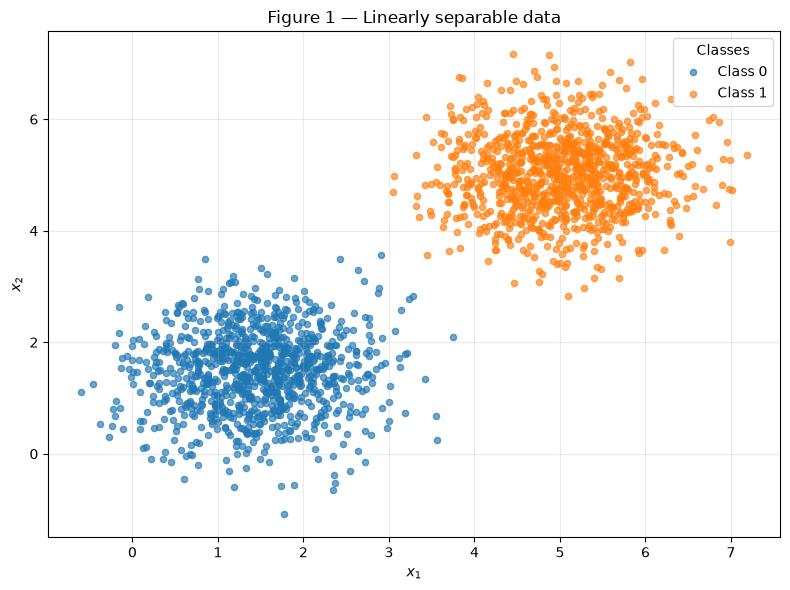

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    X_class_0[:, 0],
    X_class_0[:, 1],
    label="Class 0",
    color="tab:blue",
    alpha=0.65,
    s=20
)

ax.scatter(
    X_class_1[:, 0],
    X_class_1[:, 1],
    label="Class 1",
    color="tab:orange",
    alpha=0.65,
    s=20
)

ax.set_title("Figure 1 — Linearly separable data")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(title="Classes")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

A Figura 1 apresenta as 2.000 amostras geradas, sendo 1.000 pertencentes a cada classe. A Classe 0 está concentrada ao redor da média $[1.5, 1.5]$, enquanto a Classe 1 está concentrada ao redor da média $[5, 5]$.

Visualmente, as duas classes formam nuvens bem definidas e claramente separadas. Embora existam pontos mais afastados dos centros das distribuições, não é observada uma sobreposição relevante entre as classes. Também há uma região vazia entre as duas nuvens, na qual uma fronteira linear pode ser posicionada.

Essa separação ocorre porque a distância entre as médias é grande em relação à dispersão determinada pela matriz de covariância. Portanto, os dados apresentados constituem um caso linearmente separável, adequado para o treinamento e a análise da convergência do Perceptron.

## B — Implement the perceptron

O Perceptron calcula inicialmente uma combinação linear entre os atributos de uma amostra e seus respectivos pesos:

$$
z = \mathbf{w} \cdot \mathbf{x} + b
$$

A classe prevista é determinada pela função degrau:

$$
\hat{y} =
\begin{cases}
1, & \text{se } z \geq 0 \\
0, & \text{se } z < 0
\end{cases}
$$

Quando uma amostra é classificada incorretamente, os pesos e o viés são atualizados utilizando o erro $y-\hat{y}$:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta(y-\hat{y})\mathbf{x}
$$

$$
b \leftarrow b + \eta(y-\hat{y})
$$

Como os rótulos utilizados são $0$ e $1$, o erro pode assumir os valores $-1$, $0$ ou $1$. Uma previsão correta produz erro zero e, consequentemente, não altera os parâmetros.

In [4]:
def step(z):
    """
    Aplica a função degrau.

    Retorna 1 quando z é maior ou igual a zero
    e 0 quando z é menor que zero.
    """
    return (np.asarray(z) >= 0).astype(int)


def predict(X, w, b):
    """
    Calcula as previsões do Perceptron.

    Parameters
    ----------
    X : np.ndarray
        Matriz contendo as amostras.
    w : np.ndarray
        Vetor de pesos.
    b : float
        Termo de viés.

    Returns
    -------
    np.ndarray
        Previsões contendo apenas 0 e 1.
    """
    linear_output = X @ w + b
    return step(linear_output)


def train_perceptron(
    X,
    y,
    rng,
    learning_rate=0.01,
    max_epochs=100,
    initial_w=None,
    track_pocket=False
):
    """
    Treina o Perceptron com a regra adequada para rótulos 0 e 1.

    Quando track_pocket=True, guarda os parâmetros que alcançaram
    a maior acurácia global após uma atualização.
    """

    # Inicialização dos pesos
    if initial_w is None:
        w = rng.normal(0, 0.01, size=X.shape[1])
    else:
        w = np.asarray(initial_w, dtype=float).copy()

    initial_w_used = w.copy()
    b = 0.0

    # Históricos por época
    accuracy_history = []
    updates_history = []
    pocket_accuracy_history = []

    # Estado inicial do pocket
    initial_predictions = predict(X, w, b)
    pocket_accuracy = np.mean(initial_predictions == y)
    pocket_w = w.copy()
    pocket_b = b
    pocket_epoch = 0

    for epoch in range(max_epochs):
        updates = 0

        for x_i, y_i in zip(X, y):
            y_hat = step(np.dot(w, x_i) + b).item()
            error = y_i - y_hat

            if error != 0:
                # Regra original de atualização do Perceptron
                w = w + learning_rate * error * x_i
                b = b + learning_rate * error
                updates += 1

                # Único acréscimo para o pocket:
                # avaliar e copiar os melhores parâmetros
                if track_pocket:
                    candidate_predictions = predict(X, w, b)
                    candidate_accuracy = np.mean(
                        candidate_predictions == y
                    )

                    if candidate_accuracy > pocket_accuracy:
                        pocket_accuracy = candidate_accuracy
                        pocket_w = w.copy()
                        pocket_b = b
                        pocket_epoch = epoch + 1

        # Acurácia dos parâmetros correntes ao final da época
        predictions = predict(X, w, b)
        accuracy = np.mean(predictions == y)

        accuracy_history.append(accuracy)
        updates_history.append(updates)

        if track_pocket:
            pocket_accuracy_history.append(pocket_accuracy)

        # Mantém a condição original de parada
        if updates == 0:
            break

    return {
        "initial_w": initial_w_used,
        "w": w,
        "b": b,
        "epochs": len(accuracy_history),
        "accuracy": accuracy_history[-1],
        "accuracy_history": np.array(accuracy_history),
        "updates_history": np.array(updates_history),
        "pocket_w": pocket_w if track_pocket else None,
        "pocket_b": pocket_b if track_pocket else None,
        "pocket_accuracy": pocket_accuracy if track_pocket else None,
        "pocket_epoch": pocket_epoch if track_pocket else None,
        "pocket_accuracy_history": np.array(
            pocket_accuracy_history
        )
    }

In [5]:
test_z = np.array([-2.0, -0.1, 0.0, 0.1, 2.0])

test_X = np.array([
    [1.0, 2.0],
    [3.0, 1.0]
])

test_w = np.array([1.0, -1.0])
test_b = 0.0

print("Saída da função step:", step(test_z))
print("Previsões de teste:", predict(test_X, test_w, test_b))

Saída da função step: [0 0 1 1 1]
Previsões de teste: [0 1]


## C — Train and measure

O Perceptron foi treinado com taxa de aprendizagem $\eta=0.01$ e limite máximo de 100 épocas. O treinamento é interrompido antecipadamente quando uma passagem completa pelo conjunto de dados não produz nenhuma atualização dos parâmetros.

In [6]:
result_001 = train_perceptron(
    X=X,
    y=y,
    rng=rng,
    learning_rate=0.01,
    max_epochs=100
)

w_001 = result_001["w"]
b_001 = result_001["b"]
epochs_001 = result_001["epochs"]
accuracy_001 = result_001["accuracy"]
accuracy_history_001 = result_001["accuracy_history"]
updates_history_001 = result_001["updates_history"]

print(
    "Pesos finais:",
    np.array2string(w_001, precision=8)
)
print(f"Viés final: {b_001:.8f}")
print(f"Quantidade de épocas: {epochs_001}")
print(f"Acurácia final: {accuracy_001:.4%}")
print(f"Atualizações por época: {updates_history_001}")

Pesos finais: [0.05049707 0.02887168]
Viés final: -0.25000000
Quantidade de épocas: 26
Acurácia final: 100.0000%
Atualizações por época: [3 3 4 4 3 4 3 4 2 4 2 4 2 3 3 3 2 3 3 2 3 3 2 3 1 0]


O treinamento com taxa de aprendizagem $\eta=0.01$ convergiu após **26 épocas**. Os parâmetros finais encontrados foram:

$$
\mathbf{w} = [0.05049707,\ 0.02887168]
$$

$$
b = -0.25000000
$$

A acurácia final foi de **100%**, indicando que todas as 2.000 amostras foram classificadas corretamente. Na última época, nenhuma atualização foi realizada, atendendo à condição de parada definida para o treinamento.

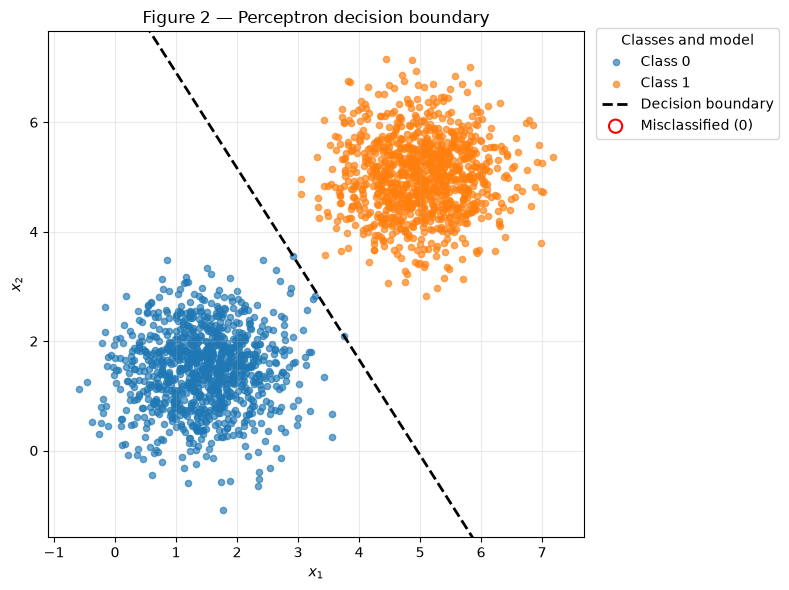

Quantidade de amostras classificadas incorretamente: 0


In [7]:
# Predições obtidas com os parâmetros finais
predictions_001 = predict(X, w_001, b_001)

# Identificação das amostras classificadas incorretamente
misclassified_001 = predictions_001 != y
n_misclassified_001 = np.sum(misclassified_001)

# Valores utilizados para desenhar a fronteira de decisão
x_boundary = np.linspace(
    X[:, 0].min() - 0.5,
    X[:, 0].max() + 0.5,
    300
)

# Da equação w1*x1 + w2*x2 + b = 0:
# x2 = -(w1*x1 + b) / w2
y_boundary = -(
    w_001[0] * x_boundary + b_001
) / w_001[1]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    X_class_0[:, 0],
    X_class_0[:, 1],
    label="Class 0",
    color="tab:blue",
    alpha=0.65,
    s=20
)

ax.scatter(
    X_class_1[:, 0],
    X_class_1[:, 1],
    label="Class 1",
    color="tab:orange",
    alpha=0.65,
    s=20
)

ax.plot(
    x_boundary,
    y_boundary,
    color="black",
    linewidth=2,
    linestyle="--",
    label="Decision boundary"
)

# Destaca os erros, caso existam
if n_misclassified_001 > 0:
    ax.scatter(
        X[misclassified_001, 0],
        X[misclassified_001, 1],
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        s=90,
        label=f"Misclassified ({n_misclassified_001})"
    )
else:
    # Entrada vazia para registrar na legenda que não houve erros
    ax.scatter(
        [],
        [],
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        s=90,
        label="Misclassified (0)"
    )

ax.set_xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

ax.set_title("Figure 2 — Perceptron decision boundary")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(title="Classes and model",bbox_to_anchor = (1.01,1.02))
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Quantidade de amostras classificadas incorretamente: {n_misclassified_001}")

A Figura 2 mostra que a fronteira de decisão aprendida pelo Perceptron foi posicionada na região vazia existente entre as duas nuvens. Os pontos da Classe 0 permanecem de um lado da fronteira, enquanto os pontos da Classe 1 permanecem do lado oposto.

Nenhuma das 2.000 amostras foi classificada incorretamente, o que é consistente com a acurácia final de 100%. Os dois pesos positivos fazem com que valores maiores de $x_1$ e $x_2$ favoreçam a previsão da Classe 1, enquanto o viés negativo desloca a fronteira de decisão para longe da origem.

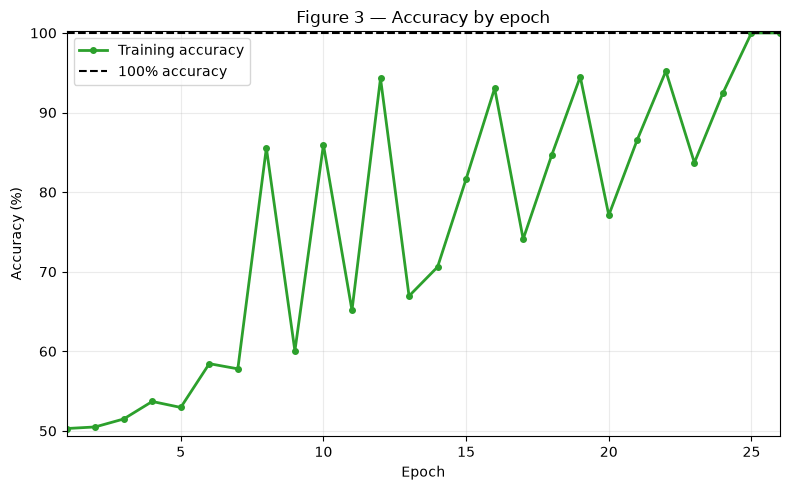

In [8]:
epochs_axis_001 = np.arange(1, epochs_001 + 1)
accuracy_percent_001 = accuracy_history_001 * 100

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    epochs_axis_001,
    accuracy_percent_001,
    color="tab:green",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Training accuracy"
)

ax.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="100% accuracy"
)

ax.set_title("Figure 3 — Accuracy by epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_xlim(1, epochs_001)
ax.set_ylim(
    max(0, accuracy_percent_001.min() - 1),
    100.2
)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

A Figura 3 mostra que a acurácia apresenta uma tendência geral de crescimento ao longo do treinamento, partindo de aproximadamente 50% e alcançando 100% nas épocas finais. Entretanto, esse crescimento não é monotônico: existem quedas temporárias entre algumas épocas.

Essas oscilações ocorrem porque a atualização causada por uma amostra classificada incorretamente desloca a fronteira de decisão. Esse deslocamento pode corrigir a amostra atual, mas também pode fazer com que outras amostras anteriormente corretas passem a ser classificadas incorretamente.

A acurácia chegou a 100% ao final da época 25, mas essa época ainda apresentou uma atualização dos parâmetros. O treinamento foi encerrado somente na época 26, quando todas as amostras foram percorridas sem nenhuma atualização. Isso confirma o cumprimento da condição de parada estabelecida.

## D — Analysis

### 1. Convergence on separable data

Os dados linearmente separáveis convergem porque existe ao menos uma fronteira linear capaz de classificar corretamente todas as amostras. Sempre que o Perceptron comete um erro, seus parâmetros são atualizados de acordo com:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta(y-\hat{y})\mathbf{x}
$$

$$
b \leftarrow b + \eta(y-\hat{y})
$$

Quando a previsão está correta, $y-\hat{y}=0$ e nenhuma atualização é realizada. Quando ocorre um erro, o sinal de $y-\hat{y}$ modifica os pesos e o viés em uma direção que favorece a classificação correta da amostra observada.

Neste treinamento, a quantidade de atualizações por época não diminuiu de forma estritamente monotônica. Nas primeiras épocas, ela oscilou principalmente entre duas e quatro atualizações, porque a correção de uma amostra podia deslocar a fronteira e afetar outras classificações. Entretanto, à medida que a fronteira se aproximou de uma posição capaz de separar as classes, os erros tornaram-se menos frequentes.

Na época 25 ocorreu apenas uma atualização, e na época 26 nenhuma atualização foi necessária. Portanto, a convergência foi confirmada quando uma passagem completa pelas 2.000 amostras terminou com zero atualizações e acurácia de 100%.

### 2. Effect of the learning rate

Para analisar o efeito da taxa de aprendizagem, o Perceptron foi treinado novamente com $\eta=1.0$. Foram mantidos os mesmos dados, a mesma ordem das amostras, o mesmo limite de épocas, o mesmo viés inicial e exatamente os mesmos pesos iniciais utilizados no treinamento com $\eta=0.01$. Dessa forma, a única variável alterada foi a taxa de aprendizagem.

In [9]:
result_100 = train_perceptron(
    X=X,
    y=y,
    rng=rng,
    learning_rate=1.0,
    max_epochs=100,
    initial_w=result_001["initial_w"]
)

w_100 = result_100["w"]
b_100 = result_100["b"]
epochs_100 = result_100["epochs"]
accuracy_100 = result_100["accuracy"]

# Direções normalizadas dos vetores de pesos
direction_001 = w_001 / np.linalg.norm(w_001)
direction_100 = w_100 / np.linalg.norm(w_100)

# Comparação angular entre as direções
cosine_similarity = np.dot(direction_001, direction_100)

angle_degrees = np.degrees(
    np.arccos(
        np.clip(cosine_similarity, -1.0, 1.0)
    )
)

print(
    "Pesos iniciais utilizados:",
    np.array2string(result_001["initial_w"], precision=8)
)
print(
    "Pesos finais com eta = 1.0:",
    np.array2string(w_100, precision=8)
)
print(f"Viés final com eta = 1.0: {b_100:.8f}")
print(f"Quantidade de épocas com eta = 1.0: {epochs_100}")
print(f"Acurácia final com eta = 1.0: {accuracy_100:.4%}")

print(
    "Direção normalizada com eta = 0.01:",
    np.array2string(direction_001, precision=8)
)
print(
    "Direção normalizada com eta = 1.0:",
    np.array2string(direction_100, precision=8)
)
print(f"Similaridade de cosseno: {cosine_similarity:.10f}")
print(f"Ângulo entre as direções: {angle_degrees:.6f} graus")

Pesos iniciais utilizados: [0.00253205 0.00895218]
Pesos finais com eta = 1.0: [5.87061596 3.3592393 ]
Viés final com eta = 1.0: -31.00000000
Quantidade de épocas com eta = 1.0: 37
Acurácia final com eta = 1.0: 100.0000%
Direção normalizada com eta = 0.01: [0.86812305 0.49634905]
Direção normalizada com eta = 1.0: [0.86794992 0.49665172]
Similaridade de cosseno: 0.9999999392
Ângulo entre as direções: 0.019978 graus


Com os mesmos pesos iniciais $\mathbf{w}_0=[0.00253205,\ 0.00895218]$, os dois treinamentos alcançaram acurácia final de 100%. Entretanto, a quantidade de épocas e os parâmetros finais foram diferentes.

| Taxa de aprendizagem | Épocas | Pesos finais | Viés final | Acurácia |
|---:|---:|---|---:|---:|
| $\eta=0.01$ | 26 | $[0.05049707,\ 0.02887168]$ | $-0.25$ | 100% |
| $\eta=1.0$ | 37 | $[5.87061596,\ 3.35923930]$ | $-31.00$ | 100% |

As direções normalizadas encontradas foram:

$$
\frac{\mathbf{w}_{0.01}}{\lVert\mathbf{w}_{0.01}\rVert}
=
[0.86812305,\ 0.49634905]
$$

$$
\frac{\mathbf{w}_{1.0}}{\lVert\mathbf{w}_{1.0}\rVert}
=
[0.86794992,\ 0.49665172]
$$

A similaridade de cosseno entre essas direções foi $0.9999999392$, equivalente a um ângulo de aproximadamente $0.019978^\circ$. Portanto, os vetores finais são quase paralelos, mas não exatamente iguais.

A taxa de aprendizagem controla o tamanho de cada correção realizada após uma classificação incorreta. Com $\eta=1.0$, cada atualização é 100 vezes maior do que com $\eta=0.01$. Como os pesos iniciais são não nulos e possuem magnitude próxima de $0.01$, a contribuição relativa dessa inicialização é diferente nos dois treinamentos.

De forma geral, após uma sequência de atualizações, os pesos podem ser escritos como:

$$
\mathbf{w}_t
=
\mathbf{w}_0
+
\eta\sum_i (y_i-\hat{y}_i)\mathbf{x}_i
$$

Como $\mathbf{w}_0\neq\mathbf{0}$ e não é multiplicado por $\eta$, alterar a taxa de aprendizagem não produz apenas uma multiplicação uniforme de todo o vetor de pesos. A trajetória da fronteira muda, podendo alterar a sequência de erros e a quantidade de épocas necessárias.

Embora as direções encontradas tenham sido muito próximas neste conjunto de dados, os vieses finais e as magnitudes dos pesos foram diferentes. Consequentemente, as fronteiras de decisão não são exatamente iguais, apesar de ambas separarem corretamente as duas classes.

| Comparação | Resultado |
|---|---|
| Ambas convergiram? | Sim |
| Ambas alcançaram 100%? | Sim |
| Mesmo número de épocas? | Não: 26 contra 37 |
| Mesma direção de `w`? | Quase, mas não exatamente |
| Mesma fronteira? | Não |
| `η = 1.0` foi mais rápido? | Não neste experimento |

### 3. Zero initialization and learning-rate invariance

Considere agora que o treinamento seja iniciado com pesos e viés nulos:

$$
\mathbf{w}_0=\mathbf{0},
\qquad
b_0=0
$$

Após uma sequência de $t$ atualizações utilizando uma taxa de aprendizagem $\eta$, os parâmetros podem ser escritos como:

$$
\mathbf{w}_t^{(\eta)}
=
\eta
\sum_{k=1}^{t}
e_k\mathbf{x}_k
$$

$$
b_t^{(\eta)}
=
\eta
\sum_{k=1}^{t}
e_k
$$

em que $e_k=y_k-\hat{y}_k$ é o erro associado à atualização $k$.

Considere dois treinamentos com taxas positivas $\eta_1$ e $\eta_2$. Se ambos começam com parâmetros nulos e recebem as amostras na mesma ordem, então:

$$
\mathbf{w}_t^{(\eta_2)}
=
\frac{\eta_2}{\eta_1}
\mathbf{w}_t^{(\eta_1)}
$$

e

$$
b_t^{(\eta_2)}
=
\frac{\eta_2}{\eta_1}
b_t^{(\eta_1)}
$$

Como $\eta_2/\eta_1>0$, a combinação linear do segundo treinamento também é apenas uma versão positivamente escalada da primeira:

$$
\mathbf{w}_t^{(\eta_2)}\cdot\mathbf{x}
+
b_t^{(\eta_2)}
=
\frac{\eta_2}{\eta_1}
\left(
\mathbf{w}_t^{(\eta_1)}\cdot\mathbf{x}
+
b_t^{(\eta_1)}
\right)
$$

A multiplicação por uma constante positiva não altera o sinal da combinação linear. Portanto, os dois treinamentos produzem a mesma previsão para cada amostra, inclusive quando a combinação linear é zero:

$$
\operatorname{step}
\left(
\mathbf{w}_t^{(\eta_2)}\cdot\mathbf{x}
+
b_t^{(\eta_2)}
\right)
=
\operatorname{step}
\left(
\mathbf{w}_t^{(\eta_1)}\cdot\mathbf{x}
+
b_t^{(\eta_1)}
\right)
$$

Como as previsões são iguais, os erros também são iguais. Consequentemente, os dois treinamentos realizam atualizações nas mesmas amostras e nas mesmas épocas, preservando a relação de proporcionalidade durante todo o processo.

Além disso, multiplicar toda a equação da fronteira por uma constante positiva não altera o conjunto de pontos que satisfaz:

$$
\mathbf{w}\cdot\mathbf{x}+b=0
$$

Logo, partindo de $\mathbf{w}_0=\mathbf{0}$ e $b_0=0$, diferentes taxas de aprendizagem produziriam parâmetros com magnitudes diferentes, mas exatamente a mesma fronteira de decisão, as mesmas previsões e o mesmo número de épocas. Por esse motivo, o enunciado exige uma inicialização não nula para que o efeito de $\eta$ possa ser analisado.

# Exercise 2

## A — Generate the data

Neste exercício, serão utilizadas duas classes bidimensionais com médias próximas e maior dispersão. Cada classe contém 1.000 amostras geradas a partir de uma distribuição normal multivariada.

Diferentemente do primeiro exercício, espera-se uma sobreposição significativa entre as duas nuvens, impedindo que todas as amostras sejam corretamente separadas por uma única fronteira linear.

In [10]:
# Quantidade de amostras por classe
n_samples_2 = 1000

# Parâmetros da Classe 0
mean_2_class_0 = np.array([3.0, 3.0])

# Parâmetros da Classe 1
mean_2_class_1 = np.array([4.0, 4.0])

# Matriz de covariância utilizada nas duas classes
covariance_2 = np.array([
    [1.5, 0.0],
    [0.0, 1.5]
])

# O mesmo rng do início do relatório continua sendo utilizado
X2_class_0 = rng.multivariate_normal(
    mean=mean_2_class_0,
    cov=covariance_2,
    size=n_samples_2
)

X2_class_1 = rng.multivariate_normal(
    mean=mean_2_class_1,
    cov=covariance_2,
    size=n_samples_2
)

# União das amostras
X2 = np.vstack((
    X2_class_0,
    X2_class_1
))

# Rótulos 0 e 1
y2 = np.concatenate((
    np.zeros(n_samples_2, dtype=int),
    np.ones(n_samples_2, dtype=int)
))

print(f"Formato de X2: {X2.shape}")
print(f"Formato de y2: {y2.shape}")
print(f"Quantidade de amostras da Classe 0: {np.sum(y2 == 0)}")
print(f"Quantidade de amostras da Classe 1: {np.sum(y2 == 1)}")

Formato de X2: (2000, 2)
Formato de y2: (2000,)
Quantidade de amostras da Classe 0: 1000
Quantidade de amostras da Classe 1: 1000


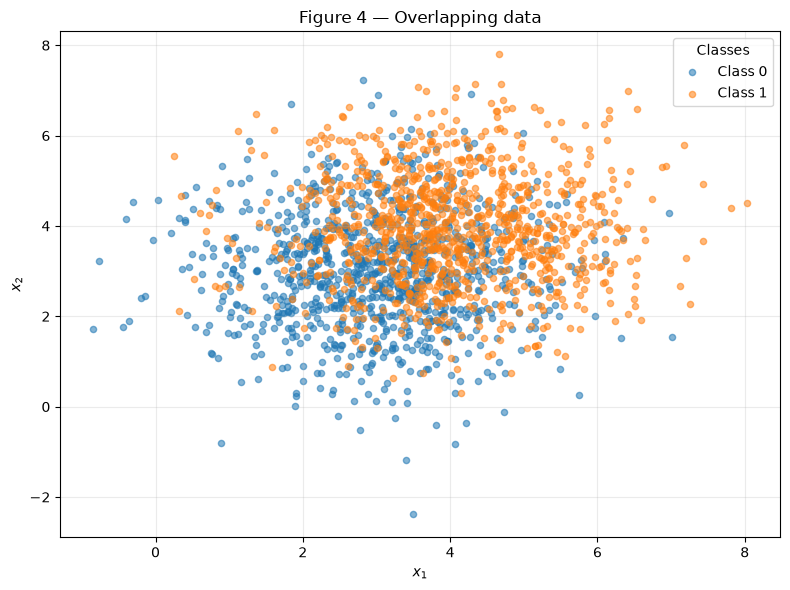

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    X2_class_0[:, 0],
    X2_class_0[:, 1],
    label="Class 0",
    color="tab:blue",
    alpha=0.55,
    s=20
)

ax.scatter(
    X2_class_1[:, 0],
    X2_class_1[:, 1],
    label="Class 1",
    color="tab:orange",
    alpha=0.55,
    s=20
)

ax.set_title("Figure 4 — Overlapping data")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(title="Classes")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

A Figura 4 apresenta as 2.000 amostras geradas, sendo 1.000 pertencentes a cada classe. A Classe 0 está concentrada ao redor da média $[3,3]$, enquanto a Classe 1 está concentrada ao redor da média $[4,4]$.

Em comparação com o Exercise 1, a distância entre as médias é menor e a variância de cada coordenada foi triplicada, passando de $0.5$ para $1.5$. Consequentemente, as duas classes apresentam uma sobreposição intensa, principalmente na região central do gráfico.

Embora seja possível observar um deslocamento geral da Classe 0 para baixo e à esquerda e da Classe 1 para cima e à direita, não existe uma região vazia capaz de separar completamente as duas nuvens. Portanto, nenhuma fronteira linear poderá classificar corretamente todas as amostras desse conjunto.

## B — Train, keeping the best weights

O mesmo Perceptron implementado no Exercise 1 foi reutilizado com taxa de aprendizagem $\eta=0.01$ e limite de 100 épocas. A função de ativação, a regra de atualização e a condição de parada permaneceram inalteradas.

Como os dados não são linearmente separáveis, também foram armazenados os parâmetros *pocket*. Após cada atualização, a acurácia foi calculada no conjunto completo. Quando uma nova melhor acurácia global foi encontrada, os pesos e o viés foram copiados e preservados.

Dessa forma, serão comparados dois resultados:

- **final weights:** parâmetros existentes ao término da centésima época;
- **pocket weights:** parâmetros que produziram a maior acurácia observada durante todo o treinamento.

In [12]:
result_2 = train_perceptron(
    X=X2,
    y=y2,
    rng=rng,
    learning_rate=0.01,
    max_epochs=100,
    track_pocket=True
)

# Parâmetros finais
w2_final = result_2["w"]
b2_final = result_2["b"]
accuracy2_final = result_2["accuracy"]

# Parâmetros pocket
w2_pocket = result_2["pocket_w"]
b2_pocket = result_2["pocket_b"]
accuracy2_pocket = result_2["pocket_accuracy"]
pocket_epoch_2 = result_2["pocket_epoch"]

# Históricos
accuracy_history_2 = result_2["accuracy_history"]
pocket_accuracy_history_2 = result_2[
    "pocket_accuracy_history"
]
updates_history_2 = result_2["updates_history"]

print(f"Quantidade de épocas: {result_2['epochs']}")

print(
    "Pesos finais:",
    np.array2string(w2_final, precision=8)
)
print(f"Viés final: {b2_final:.8f}")
print(f"Acurácia dos parâmetros finais: {accuracy2_final:.4%}")

print(
    "Pesos pocket:",
    np.array2string(w2_pocket, precision=8)
)
print(f"Viés pocket: {b2_pocket:.8f}")
print(f"Acurácia dos parâmetros pocket: {accuracy2_pocket:.4%}")
print(f"Época em que o melhor pocket ocorreu: {pocket_epoch_2}")

Quantidade de épocas: 100
Pesos finais: [0.05448404 0.0480433 ]
Viés final: -0.07000000
Acurácia dos parâmetros finais: 50.1500%
Pesos pocket: [0.01066397 0.00872652]
Viés pocket: -0.07000000
Acurácia dos parâmetros pocket: 71.1000%
Época em que o melhor pocket ocorreu: 86


O treinamento atingiu o limite máximo de **100 épocas**, pois os dados sobrepostos impediram que uma passagem completa pelo conjunto ocorresse sem atualizações.

Ao término da centésima época, os parâmetros correntes eram:

$$
\mathbf{w}_{final}
=
[0.05448404,\ 0.04804330]
$$

$$
b_{final}=-0.07000000
$$

A acurácia desses parâmetros finais foi de **50.15%**.

Os melhores parâmetros armazenados pelo pocket foram:

$$
\mathbf{w}_{pocket}
=
[0.01066397,\ 0.00872652]
$$

$$
b_{pocket}=-0.07000000
$$

A acurácia do pocket foi de **71.10%**, e esse melhor resultado foi encontrado durante a **época 86**.

Portanto, os parâmetros existentes ao final do treinamento não correspondem aos melhores parâmetros encontrados ao longo do processo. O pocket preservou uma solução aproximadamente 20.95 pontos percentuais melhor do que a iteração final.

## C — Figures

A seguir, as fronteiras produzidas pelos parâmetros finais e pelos parâmetros pocket são comparadas sobre o mesmo conjunto de dados. Os erros de cada solução são apresentados separadamente para preservar a legibilidade da figura.

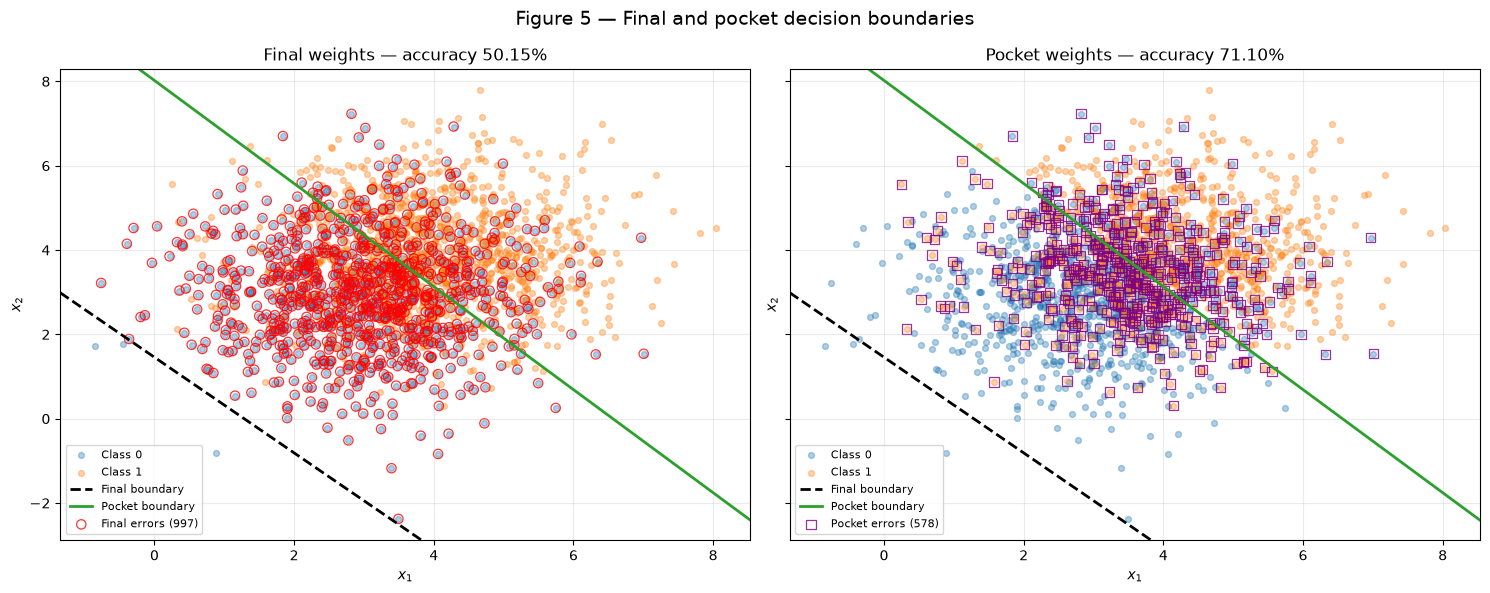

Erros dos parâmetros finais: 997
Erros dos parâmetros pocket: 578


In [13]:
# Predições das duas soluções
predictions2_final = predict(
    X2,
    w2_final,
    b2_final
)

predictions2_pocket = predict(
    X2,
    w2_pocket,
    b2_pocket
)

# Identificação dos erros
misclassified2_final = predictions2_final != y2
misclassified2_pocket = predictions2_pocket != y2

n_misclassified2_final = np.sum(misclassified2_final)
n_misclassified2_pocket = np.sum(misclassified2_pocket)

# Intervalo comum para as fronteiras
x_boundary_2 = np.linspace(
    X2[:, 0].min() - 0.5,
    X2[:, 0].max() + 0.5,
    300
)

# Fronteira dos parâmetros finais
y_boundary2_final = -(
    w2_final[0] * x_boundary_2 + b2_final
) / w2_final[1]

# Fronteira dos parâmetros pocket
y_boundary2_pocket = -(
    w2_pocket[0] * x_boundary_2 + b2_pocket
) / w2_pocket[1]


def plot_exercise_2_panel(
    ax,
    misclassified,
    error_label,
    error_color,
    error_marker,
    panel_title
):
    """Desenha um painel comparando as duas fronteiras."""

    ax.scatter(
        X2_class_0[:, 0],
        X2_class_0[:, 1],
        label="Class 0",
        color="tab:blue",
        alpha=0.35,
        s=18
    )

    ax.scatter(
        X2_class_1[:, 0],
        X2_class_1[:, 1],
        label="Class 1",
        color="tab:orange",
        alpha=0.35,
        s=18
    )

    ax.plot(
        x_boundary_2,
        y_boundary2_final,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Final boundary"
    )

    ax.plot(
        x_boundary_2,
        y_boundary2_pocket,
        color="tab:green",
        linestyle="-",
        linewidth=2,
        label="Pocket boundary"
    )

    ax.scatter(
        X2[misclassified, 0],
        X2[misclassified, 1],
        facecolors="none",
        edgecolors=error_color,
        marker=error_marker,
        linewidths=0.9,
        s=45,
        alpha=0.8,
        label=error_label
    )

    ax.set_title(panel_title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharex=True,
    sharey=True
)

plot_exercise_2_panel(
    ax=axes[0],
    misclassified=misclassified2_final,
    error_label=f"Final errors ({n_misclassified2_final})",
    error_color="red",
    error_marker="o",
    panel_title=(
        f"Final weights — accuracy {accuracy2_final:.2%}"
    )
)

plot_exercise_2_panel(
    ax=axes[1],
    misclassified=misclassified2_pocket,
    error_label=f"Pocket errors ({n_misclassified2_pocket})",
    error_color="purple",
    error_marker="s",
    panel_title=(
        f"Pocket weights — accuracy {accuracy2_pocket:.2%}"
    )
)

axes[0].set_xlim(
    X2[:, 0].min() - 0.5,
    X2[:, 0].max() + 0.5
)

axes[0].set_ylim(
    X2[:, 1].min() - 0.5,
    X2[:, 1].max() + 0.5
)

fig.suptitle(
    "Figure 5 — Final and pocket decision boundaries",
    fontsize=14
)

plt.tight_layout()
plt.show()

print(
    "Erros dos parâmetros finais:",
    n_misclassified2_final
)
print(
    "Erros dos parâmetros pocket:",
    n_misclassified2_pocket
)

A Figura 5 mostra que a fronteira associada aos parâmetros finais está posicionada abaixo da maior parte das duas nuvens. Como os pesos finais são positivos, quase todos os pontos ficam no lado classificado como Classe 1. Consequentemente, o modelo acerta grande parte da Classe 1, mas classifica incorretamente quase toda a Classe 0, totalizando **997 erros** e acurácia de **50.15%**.

A fronteira pocket atravessa a região central dos dados e acompanha melhor o deslocamento existente entre as distribuições. Embora a sobreposição impeça a separação perfeita, essa fronteira produz somente **578 erros**, alcançando acurácia de **71.10%**.

As duas soluções possuem o mesmo viés final, $b=-0.07$, mas diferentes magnitudes dos pesos. Como a posição da fronteira depende da relação entre pesos e viés, e não apenas do valor isolado de $b$, as duas retas aparecem em posições bastante diferentes.

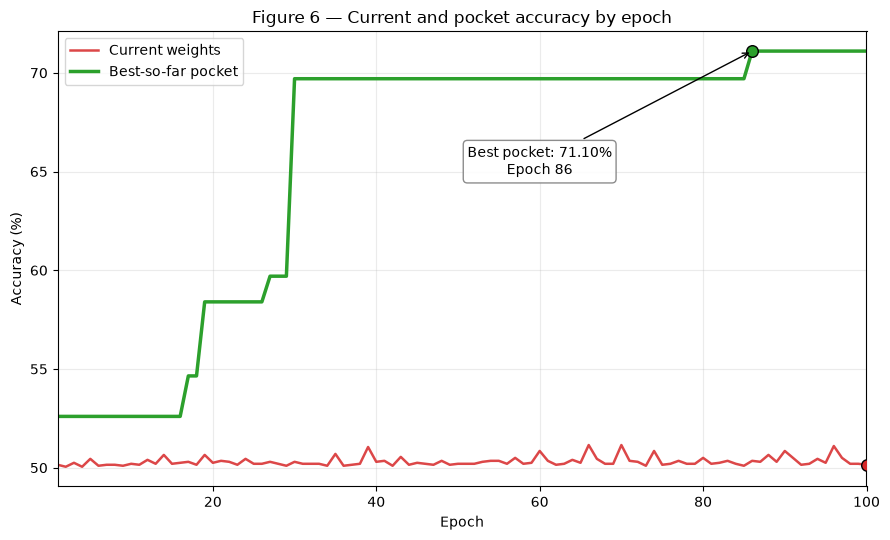

In [14]:
epochs_axis_2 = np.arange(
    1,
    len(accuracy_history_2) + 1
)

current_accuracy_percent_2 = (
    accuracy_history_2 * 100
)

pocket_accuracy_percent_2 = (
    pocket_accuracy_history_2 * 100
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    epochs_axis_2,
    current_accuracy_percent_2,
    color="tab:red",
    linewidth=1.8,
    alpha=0.85,
    label="Current weights"
)

ax.plot(
    epochs_axis_2,
    pocket_accuracy_percent_2,
    color="tab:green",
    linewidth=2.5,
    label="Best-so-far pocket"
)

# Destaque do melhor pocket
ax.scatter(
    pocket_epoch_2,
    accuracy2_pocket * 100,
    color="tab:green",
    edgecolor="black",
    s=70,
    zorder=3
)

ax.annotate(
    (
        f"Best pocket: {accuracy2_pocket:.2%}\n"
        f"Epoch {pocket_epoch_2}"
    ),
    xy=(
        pocket_epoch_2,
        accuracy2_pocket * 100
    ),
    xytext=(60, 65.5),
    textcoords="data",
    ha="center",
    va="center",
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.9
    },
    arrowprops={
        "arrowstyle": "->",
        "color": "black",
        "linewidth": 1
    }
)

# Destaque da iteração final
ax.scatter(
    result_2["epochs"],
    accuracy2_final * 100,
    color="tab:red",
    edgecolor="black",
    s=70,
    zorder=3
)

ax.set_title(
    "Figure 6 — Current and pocket accuracy by epoch"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_xlim(1, result_2["epochs"])

minimum_accuracy_2 = min(
    current_accuracy_percent_2.min(),
    pocket_accuracy_percent_2.min()
)

maximum_accuracy_2 = max(
    current_accuracy_percent_2.max(),
    pocket_accuracy_percent_2.max()
)

ax.set_ylim(
    max(0, minimum_accuracy_2 - 1),
    min(100, maximum_accuracy_2 + 1)
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

A Figura 6 mostra comportamentos bastante diferentes entre a acurácia dos parâmetros correntes e a melhor acurácia armazenada pelo pocket.

A curva dos parâmetros correntes permanece próxima de 50% durante as 100 épocas e apresenta oscilações contínuas. Isso ocorre porque os dados não são linearmente separáveis: sempre existem amostras classificadas incorretamente, fazendo com que o Perceptron continue atualizando os parâmetros e deslocando sua fronteira.

A curva pocket apresenta um comportamento em degraus e nunca diminui. Cada subida representa uma atualização que produziu uma acurácia superior a todas as observadas anteriormente. Nos intervalos horizontais, o treinamento continuou realizando atualizações, mas nenhuma delas superou o melhor resultado já armazenado.

O pocket permaneceu próximo de 69.7% durante grande parte do treinamento e atingiu sua melhor acurácia, **71.10%**, na época **86**. Depois disso, nenhuma atualização produziu uma solução melhor. Ao final da época 100, os parâmetros correntes apresentaram somente **50.15%**, enquanto o pocket preservou os melhores parâmetros encontrados.

## D — Analysis

### 1. Final parameters versus pocket parameters

Para compreender a diferença entre as duas fronteiras, foram comparadas as magnitudes dos vetores de pesos, a distância de cada fronteira até a origem e a magnitude típica das amostras.

In [15]:
# Magnitude típica das amostras do Exercise 2
mean_sample_norm_2 = np.mean(
    np.linalg.norm(X2, axis=1)
)

# Magnitudes dos vetores de pesos
final_weight_norm_2 = np.linalg.norm(w2_final)
pocket_weight_norm_2 = np.linalg.norm(w2_pocket)

# Distância perpendicular da fronteira à origem:
# |b| / ||w||
final_boundary_distance_2 = (
    abs(b2_final) / final_weight_norm_2
)

pocket_boundary_distance_2 = (
    abs(b2_pocket) / pocket_weight_norm_2
)

# Magnitude média aproximada de uma atualização dos pesos
mean_weight_update_2 = (
    0.01 * mean_sample_norm_2
)

# Magnitude de uma atualização do viés
bias_update_2 = 0.01

print(
    f"Norma média das amostras: "
    f"{mean_sample_norm_2:.6f}"
)

print(
    f"Norma dos pesos finais: "
    f"{final_weight_norm_2:.6f}"
)

print(
    f"Norma dos pesos pocket: "
    f"{pocket_weight_norm_2:.6f}"
)

print(
    f"Distância da fronteira final à origem: "
    f"{final_boundary_distance_2:.6f}"
)

print(
    f"Distância da fronteira pocket à origem: "
    f"{pocket_boundary_distance_2:.6f}"
)

print(
    f"Magnitude média da atualização dos pesos: "
    f"{mean_weight_update_2:.6f}"
)

print(
    f"Magnitude da atualização do viés: "
    f"{bias_update_2:.6f}"
)

print(
    f"Razão aproximada entre as atualizações: "
    f"{mean_weight_update_2 / bias_update_2:.6f}"
)

Norma média das amostras: 5.110834
Norma dos pesos finais: 0.072641
Norma dos pesos pocket: 0.013779
Distância da fronteira final à origem: 0.963647
Distância da fronteira pocket à origem: 5.080038
Magnitude média da atualização dos pesos: 0.051108
Magnitude da atualização do viés: 0.010000
Razão aproximada entre as atualizações: 5.110834


Os parâmetros finais e pocket possuem o mesmo viés, $b=-0.07$, mas seus vetores de pesos têm magnitudes bastante diferentes:

$$
\lVert\mathbf{w}_{final}\rVert
=
0.072641
$$

$$
\lVert\mathbf{w}_{pocket}\rVert
=
0.013779
$$

A distância perpendicular entre uma fronteira linear e a origem é dada por:

$$
d=\frac{|b|}{\lVert\mathbf{w}\rVert}
$$

Com os parâmetros finais, essa distância foi de aproximadamente $0.963647$. Para os parâmetros pocket, ela foi de aproximadamente $5.080038$. Isso explica a diferença observada na Figura 5: a fronteira final ficou próxima da origem e abaixo da maior parte dos dados, enquanto a fronteira pocket atravessou a região central das nuvens.

A fronteira final classifica quase todas as amostras como Classe 1. Como o conjunto é balanceado, esse comportamento produz uma acurácia próxima de uma escolha aleatória: **50.15%**. A fronteira pocket aproveita o deslocamento existente entre as distribuições e alcança **71.10%**, embora a sobreposição impeça uma classificação perfeita.

A diferença de deslocamento também pode ser explicada pela regra de atualização. A norma média das amostras foi:

$$
\operatorname{média}(\lVert\mathbf{x}\rVert)
=
5.110834
$$

Para $\eta=0.01$, a magnitude típica de uma atualização dos pesos é aproximadamente:

$$
\lVert\Delta\mathbf{w}\rVert
=
\eta\lVert\mathbf{x}\rVert
\approx
0.051108
$$

Enquanto a magnitude da atualização do viés é:

$$
|\Delta b|=\eta=0.01
$$

Portanto, a atualização dos pesos é, em média, aproximadamente **5.11 vezes maior** do que a atualização do viés. Como os dados não são separáveis, erros continuam ocorrendo e os pesos podem sofrer deslocamentos relativamente grandes em comparação com o viés.

Além disso, as amostras estão organizadas com todas as observações da Classe 0 antes das observações da Classe 1. Assim, no final de cada época, as últimas correções são provocadas principalmente por amostras da Classe 1. Como não existe uma fronteira capaz de satisfazer simultaneamente todas as amostras, essas correções podem afastar o modelo de uma solução anteriormente melhor.

O laço de treinamento não verifica se a nova atualização melhora permanentemente a acurácia. Ele apenas corrige a amostra atual. Por isso, o treinamento terminou em uma fronteira ruim após a centésima época, enquanto o pocket preservou os parâmetros encontrados na época 86 antes que atualizações posteriores reduzissem novamente o desempenho.

### 2. Perceptron convergence theorem

A Figura 3 e a Figura 6 apresentam comportamentos diferentes porque apenas o conjunto do Exercise 1 satisfaz a hipótese fundamental do teorema da convergência do Perceptron.

O teorema estabelece que, para um conjunto finito de dados linearmente separável, o Perceptron encontrará uma fronteira separadora após um número finito de atualizações. Em outras palavras, se existe um vetor de pesos e um viés capazes de classificar corretamente todas as amostras com uma margem positiva, o algoritmo eventualmente completa uma época sem erros e interrompe o treinamento.

No Exercise 1, as duas classes são linearmente separáveis. Por isso, apesar das oscilações intermediárias da acurácia, o modelo alcançou 100% e encerrou o treinamento na época 26, quando uma passagem completa ocorreu sem nenhuma atualização.

No Exercise 2, as distribuições apresentam forte sobreposição. Existem amostras das duas classes ocupando as mesmas regiões do espaço, de modo que nenhuma reta consegue classificá-las simultaneamente sem erros. Portanto, foi violada a hipótese de **separabilidade linear** exigida pelo teorema.

Como não existe uma fronteira perfeita, qualquer reta deixa parte das amostras no lado incorreto. Quando o Perceptron corrige um desses erros, a fronteira se desloca e pode criar ou recuperar erros em outras amostras. Consequentemente, o número de atualizações nunca chega a zero.

Isso explica a diferença entre as curvas:

- na Figura 3, a acurácia alcança 100% e o treinamento termina;
- na Figura 6, a acurácia corrente continua oscilando próxima de 50% durante as 100 épocas;
- a curva pocket preserva a melhor solução encontrada, mas não representa convergência do algoritmo original.

Assim, o comportamento observado no Exercise 2 não contradiz o teorema da convergência. O teorema simplesmente não fornece garantia quando os dados não são linearmente separáveis.

### 3. More epochs and a smaller learning rate

Adicionar mais épocas não resolve o problema fundamental. Como os dados não são linearmente separáveis, qualquer fronteira produz pelo menos alguns erros. Enquanto existirem erros, a regra do Perceptron continuará alterando os parâmetros:

$$
\mathbf{w}
\leftarrow
\mathbf{w}
+
\eta(y-\hat{y})\mathbf{x}
$$

$$
b
\leftarrow
b
+
\eta(y-\hat{y})
$$

Uma atualização pode corrigir a amostra atual, mas também pode fazer com que outras amostras passem para o lado incorreto da fronteira. Como não existe uma solução que satisfaça todas as amostras simultaneamente, executar mais épocas apenas prolonga essa sequência de correções conflitantes.

Mais épocas poderiam eventualmente permitir que o pocket encontrasse outra solução ligeiramente melhor, mas não fariam o Perceptron tradicional convergir nem permitiriam alcançar 100% de acurácia. A inexistência de um separador perfeito continua sendo a mesma, independentemente da duração do treinamento.

Reduzir a taxa de aprendizagem também não elimina o problema. Uma taxa menor multiplica tanto a atualização dos pesos quanto a atualização do viés por uma constante positiva menor:

$$
\Delta\mathbf{w}
=
\eta(y-\hat{y})\mathbf{x}
$$

$$
\Delta b
=
\eta(y-\hat{y})
$$

Isso reduz o tamanho de cada deslocamento da fronteira, mas não modifica o sentido da correção nem remove os erros causados pela sobreposição. As amostras conflitantes continuam produzindo atualizações sucessivas.

Portanto, uma taxa menor pode tornar as mudanças dos parâmetros mais graduais e alterar a trajetória numérica do treinamento, mas não cria uma fronteira linear que não existe. O algoritmo continuará sem uma época completa livre de erros.

Assim:

- **mais épocas** prolongam as oscilações, mas não garantem convergência;
- **uma taxa menor** reduz o tamanho das atualizações, mas não elimina os conflitos;
- o pocket preserva uma boa solução encontrada, porém não transforma dados sobrepostos em dados linearmente separáveis.

## Implementation approach and challenges

O Perceptron foi implementado do zero utilizando NumPy. A implementação foi dividida em uma função degrau, uma função de predição e uma função de treinamento. Para cada amostra, o modelo calcula a combinação linear $\mathbf{w}\cdot\mathbf{x}+b$, aplica a função degrau e atualiza os parâmetros somente quando a previsão está incorreta.

O treinamento registra a acurácia e a quantidade de atualizações após cada época. Para os dados sobrepostos, a mesma função foi reutilizada com o acompanhamento opcional do pocket. Após cada atualização, os parâmetros eram copiados quando produziam uma nova melhor acurácia global.

As principais dificuldades foram manter a sequência correta do único gerador aleatório, garantir a utilização dos mesmos pesos iniciais na comparação entre as taxas de aprendizagem e implementar o pocket exatamente após cada atualização. Também foi necessário distinguir convergência, melhor resultado observado e parâmetros existentes ao final do treinamento.

## Use of artificial intelligence

O ChatGPT foi utilizado para interpretar o enunciado e a rubrica, organizar o relatório, auxiliar na elaboração inicial do código de geração dos dados e do Perceptron e estruturar o acompanhamento dos parâmetros pocket.

A ferramenta também auxiliou na revisão das equações, na comparação das taxas de aprendizagem, na demonstração algébrica da inicialização nula, na identificação de um problema de reprodutibilidade relacionado à ordem de execução do gerador aleatório e na revisão técnica e visual das Figuras 1 a 6.

# Results summary

| # | Quantity | Value |
|---:|---|---|
| 1 | Exercise 1 — final $\mathbf{w}$ and $b$ | $\mathbf{w}=[0.05049707,\ 0.02887168]$; $b=-0.25000000$ |
| 2 | Exercise 1 — epochs to convergence | 26 |
| 3 | Exercise 1 — final accuracy | 100.00% |
| 4 | Exercise 1 — epochs and final accuracy with $\eta=1.0$ | 37 epochs; 100.00% |
| 5 | Exercise 2 — final $\mathbf{w}$ and $b$ | $\mathbf{w}=[0.05448404,\ 0.04804330]$; $b=-0.07000000$ |
| 6 | Exercise 2 — accuracy of the final weights | 50.15% |
| 7 | Exercise 2 — accuracy of the pocket weights | 71.10% |
| 8 | Exercise 2 — epoch at which the pocket best occurred | 86 |